<div style="background:linear-gradient(135deg,#01172F 0%,#123B62 68%,#D9A441 140%);padding:30px;border-radius:18px;color:white;margin:8px 0 24px 0;box-shadow:0 8px 24px #01172F22">
  <div style="font-size:12px;letter-spacing:1.8px;font-weight:700;color:#E8C87E">LIA · ENTREGA 1.2 · 02 DE 03</div>
  <h1 style="margin:10px 0 8px 0;font-size:34px;line-height:1.16;color:white">IoT Security & Energy: quando o dataset engana</h1>
  <p style="font-size:17px;line-height:1.55;margin:0 0 16px 0;color:#E8EEF5">Uma perícia de proveniência para separar sinal real de números convincentes.</p>
  <span style="display:inline-block;background:#FFFFFF22;border:1px solid #FFFFFF55;padding:5px 10px;border-radius:999px;margin:3px 4px 0 0;font-size:12px">Pandas</span> <span style="display:inline-block;background:#FFFFFF22;border:1px solid #FFFFFF55;padding:5px 10px;border-radius:999px;margin:3px 4px 0 0;font-size:12px">IoT</span> <span style="display:inline-block;background:#FFFFFF22;border:1px solid #FFFFFF55;padding:5px 10px;border-radius:999px;margin:3px 4px 0 0;font-size:12px">Proveniência</span>
</div>

| 📦 Dataset | 📄 Arquivo | 📐 Dimensões | 🎯 Papel |
|---|---|---:|---|
| IoT Network Security and Energy | `d2.csv` | **4.000 × 24** | Controle metodológico |

> **Saída deste notebook:** `resultados/entrega_1_2.json`

## ⚡ Em 30 segundos

- **15 de 20** variáveis numéricas são compatíveis com distribuições uniformes.
- A correlação máxima entre variáveis é apenas **0,0461**, mesmo onde o domínio sugere relações físicas.
- O conjunto recebe o veredito **sintético** e não sustenta uma conclusão operacional de segurança.

## 🗺️ Roteiro do notebook

| | Etapa | O que acontece |
|---:|---|---|
| 🔍 | **Auditar** | estrutura, classes, duplicatas e vazamento |
| 🧬 | **Investigar** | uniformidade, outliers e correlações |
| 🧪 | **Validar** | comparar com o RT-IoT2022 e controlar o tamanho amostral |
| 💾 | **Registrar** | salvar o veredito com rastreabilidade |

> ▶️ **Como usar:** execute as células de cima para baixo. A primeira célula monta o Drive, confere os arquivos e prepara o ambiente.

---

## 🎯 1. Escopo

### 1.1 Questão de pesquisa

> Os dados deste conjunto sustentam a proveniência que ele declara, e há informação suficiente para responder à pergunta de segurança originalmente pretendida?

### 1.2 Papel na Entrega 1

A pergunta original desta entrega seria a caracterização de ataques a dispositivos
IoT em função de parâmetros de consumo energético. A auditoria da Seção 6 mostra que
os dados não a sustentam.

Em vez de descartar a entrega, ela é reformulada: **como reconhecer um conjunto de
dados sintético antes de extrair conclusões dele?** A resposta é diretamente
reaproveitável em qualquer pipeline de ingestão, e valida o veredito favorável que a
Entrega 1.3 recebe do mesmo procedimento.

### 1.3 Pré-requisitos de execução

- Entrega 1.1 executada — as convenções são herdadas dela
- `scipy.stats` para os testes de Kolmogorov–Smirnov e qui-quadrado
- `nucleo.py`, `titanic.csv` e `d2.csv` no diretório apontado por `DADOS`


---

## 🧭 2. Matriz de rastreabilidade

Mapa rápido entre o desafio, a seção e a evidência gerada.

| Requisito | Seção | Evidência produzida |
|---|---|---|
| Limpeza dos dados | 5 e 7 | duplicatas, perfil, padronização; e a justificativa para não limpar |
| Análise exploratória | 5 e 6 | triagem por η², cinco testes de proveniência |
| Visualizações informativas | 8 | distribuição, correlação, comparação entre fontes |
| Identificação de insights | 6, 7 e 8 | veredito validado contra controles |
| Conclusões e recomendações | 10 | procedimento de auditoria de proveniência |


---

## 📐 3. Convenções e premissas

### 3.1 Convenções estatísticas

Fixadas em `nucleo.CONVENCOES` e idênticas nas três entregas. A célula de
calibração da Seção 4 interrompe a execução se qualquer uma divergir.

| Convenção | Valor adotado | Alternativa comum | Efeito da troca |
|---|---|---|---|
| Quantil | interpolação linear (tipo 7 de Hyndman–Fan) | tipo 1 (sem interpolação) | altera contagem de outliers |
| Desvio padrão | `ddof=1` (amostral) | `ddof=0` (populacional, padrão do NumPy) | altera dispersão reportada |
| Outlier | regra de Tukey, `1,5 × IQR` | `3σ` | altera critério de exclusão |
| Correlação | Pearson | Spearman | altera sensibilidade a não-linearidade |

### 3.2 Premissas declaradas

**P1. Escopo do veredito** — a conclusão é sobre a natureza estatística dos dados, não sobre intenção de quem os publicou.

**P2. Redação adotada** — "conjunto sintético cuja documentação não declara a natureza sintética". É o que a evidência sustenta; afirmar intenção de enganar iria além dela.

**P3. Ausência de limpeza** — nenhuma limpeza é aplicada ao conjunto. Limpar dados sem sinal não cria sinal — produziria a aparência de análise sobre ruído.

**P4. Uso na Entrega 1** — nenhum resultado substantivo deste conjunto entra na conclusão final. A contribuição é exclusivamente metodológica.

**P5. Nível de significância** — α = 0,05 em todos os testes de hipótese desta entrega.



---

## ⚙️ 4. Preparação do ambiente

In [15]:
# @title ⚙️ Preparar ambiente e conferir arquivos
import importlib.util
import json
import math
import os
import subprocess
import sys
import urllib.request
from pathlib import Path

# Caminho principal no Google Drive. No Colab, você pode editar pelo formulário.
PASTA_PROJETO = "/content/drive/MyDrive/Entrega1"  # @param {"type":"string"}
try:
    EM_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    EM_COLAB = False

if EM_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DADOS = Path(PASTA_PROJETO)
else:
    DADOS = Path.cwd()

if not DADOS.exists():
    raise FileNotFoundError(
        f"Pasta não encontrada: {DADOS}\n"
        "Crie MyDrive/Entrega1, envie o pacote e execute esta célula novamente."
    )

os.chdir(DADOS)
sys.path.insert(0, str(DADOS))
Path("resultados").mkdir(exist_ok=True)

# Arquivos didáticos pequenos: baixa somente se ainda não estiverem na pasta.
DOWNLOADS = {
    "titanic.csv": "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv",
    "iris.csv": "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv",
}
for nome, url in DOWNLOADS.items():
    if not Path(nome).exists():
        print(f"⬇️ Baixando {nome}...")
        urllib.request.urlretrieve(url, nome)

# Instala apenas o que estiver ausente no ambiente atual.
PACOTES = {
    "numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
    "seaborn": "seaborn", "scipy": "scipy", "pyarrow": "pyarrow",
}
faltam_pacotes = [pacote for modulo, pacote in PACOTES.items()
                   if importlib.util.find_spec(modulo) is None]
if faltam_pacotes:
    print("📦 Instalando:", ", ".join(faltam_pacotes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltam_pacotes])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats

import nucleo as nu

nu.aplicar_estilo()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

ITENS = {
    "nucleo.py": "módulo compartilhado",
    "titanic.csv": "calibração",
    "iris.csv": "teste de quantis e correlação",
    "d2.csv": "IoT Security & Energy",
    "d3.csv": "RT-IoT2022",
    "resultados/entrega_1_1.json": "resultado da etapa 1.1",
    "resultados/entrega_1_2.json": "resultado da etapa 1.2",
}
painel = pd.DataFrame([
    {"status": "✅ OK" if Path(arquivo).exists() else "⬜ pendente",
      "arquivo": arquivo, "papel": papel}
    for arquivo, papel in ITENS.items()
])
display(painel)

obrigatorios = ['nucleo.py', 'titanic.csv', 'd2.csv', 'd3.csv']
faltando = [arquivo for arquivo in obrigatorios if not Path(arquivo).exists()]
if faltando:
    raise FileNotFoundError(
        "Arquivos necessários para esta etapa:\n- " + "\n- ".join(faltando)
    )

print(f"✅ Ambiente pronto · {DADOS}")
print("📐 Convenções:", nu.CONVENCOES)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,status,arquivo,papel
0,✅ OK,nucleo.py,módulo compartilhado
1,✅ OK,titanic.csv,calibração
2,✅ OK,iris.csv,teste de quantis e correlação
3,✅ OK,d2.csv,IoT Security & Energy
4,✅ OK,d3.csv,RT-IoT2022
5,✅ OK,resultados/entrega_1_1.json,resultado da etapa 1.1
6,✅ OK,resultados/entrega_1_2.json,resultado da etapa 1.2


✅ Ambiente pronto · /content/drive/MyDrive/Entrega1
📐 Convenções: {'quantil': 'linear', 'ddof': 1, 'outlier': '1.5*IQR', 'corr': 'pearson'}


In [16]:
# @title ▶️ ⚙️ 4. Preparação do ambiente
# Regressão de convenções. Verifica 6 grupos do Titanic contra valores
# conhecidos. Interrompe a execução se qualquer convenção tiver mudado.
assert nu.calibrar("titanic.csv"), "convenções divergiram — investigar antes de prosseguir"

calibracao: OK -- 6/6 grupos, age nulos=177 | convencoes={'quantil': 'linear', 'ddof': 1, 'outlier': '1.5*IQR', 'corr': 'pearson'}


---

## 🔍 5. Auditoria de entrada

### 5.1 Integridade e estrutura

> 🎯 **Pergunta:** Caracterizar o arquivo e listar o esquema.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Verificação de integridade idêntica à da Entrega 1.1, seguida da listagem completa de colunas — necessária porque a análise do esquema precede a estatística.

</details>

In [17]:
# @title ▶️ 5.1 Integridade e estrutura
df = nu.carregar("d2.csv", cache=False,
                categoricas=("Device_Type", "ATTACK", "DATASET"))

integridade = nu.integridade("d2.csv", df)
print("Integridade:", integridade)
print(f"Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print()
print("Esquema:")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:2d}. {c}")

Integridade: {'md5': 'cd09503e4bec', 'linhas_wc': 4000, 'linhas_parser': 4000, 'confere': True}
Dimensões: 4,000 linhas × 24 colunas

Esquema:
   1. Device_ID
   2. Device_Type
   3. BS_position
   4. No_of_sensors
   5. Threshold_distance
   6. Energy_consumed_by_amplifier_long_distance
   7. Initial_energy
   8. Cluster_radius
   9. Energy_consumed_by_electronics_circuit
  10. Energy_consumed_by_amplifier_short_distance
  11. Simulation_time
  12. Secondary_model_parameter_value
  13. Bandwidth
  14. Data_packet_size
  15. Message_size
  16. ICMP_IPV4_TYPE
  17. ICMP_TYPE
  18. DNS_QUERY_ID
  19. DNS_QUERY_TYPE
  20. DNS_TTL_ANSWER
  21. FTP_COMMAND_RET_CODE
  22. ATTACK
  23. LABEL
  24. DATASET


**Interpretação — a primeira anomalia é estrutural.**

O esquema combina dois domínios que não coexistem em um mesmo registro:

| Grupo | Colunas | Origem do dado |
|---|---|---|
| Modelo de rádio | `Initial_energy`, `Cluster_radius`, `Threshold_distance`, `Energy_consumed_by_amplifier_long_distance`, `Energy_consumed_by_amplifier_short_distance` | **parâmetros de entrada** de simulação de rede de sensores (modelo de energia tipo LEACH) |
| Fluxo de rede | `DNS_QUERY_ID`, `DNS_TTL_ANSWER`, `ICMP_TYPE`, `FTP_COMMAND_RET_CODE` | **campos observados** em captura de tráfego |

Parâmetros de configuração de um simulador de consumo de rádio e campos de cabeçalho
DNS observados em rede não são medidos no mesmo evento. Um antecede a simulação; o
outro resulta de observação.

Essa leitura custa poucos minutos e não depende de nenhum teste estatístico.

### 5.2 Perfil e duplicatas

> 🎯 **Pergunta:** Quantificar ausências e verificar repetição de registros.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Perfil por coluna e contagem de duplicatas. Em dados gerados por sorteio independente, a probabilidade de duas linhas coincidirem em vinte variáveis contínuas é praticamente nula — a contagem de duplicatas é, portanto, informativa sobre o processo gerador.

</details>

In [18]:
# @title ▶️ 5.2 Perfil e duplicatas
perfil = nu.perfil(df)
display(perfil)

dup_total = int(df.duplicated().sum())
num_cols = df.select_dtypes(include=[np.number]).columns
dup_num = int(df.duplicated(subset=list(num_cols)).sum())

print(f"Duplicatas de linha inteira.........: {dup_total}")
print(f"Duplicatas nas {len(num_cols)} colunas numéricas: {dup_num}")
print(f"Ausências totais no conjunto........: {int(df.isna().sum().sum())}")

,coluna,dtype,nulos,nulos_%,vazios_str,unicos,constante
0,Device_ID,object,0,0.0,0,4000,False
1,Device_Type,category,0,0.0,0,5,False
2,BS_position,float64,0,0.0,0,3928,False
3,No_of_sensors,int64,0,0.0,0,490,False
4,Threshold_distance,float64,0,0.0,0,3619,False
5,Energy_consumed_by_amplifier_long_distance,float64,0,0.0,0,4000,False
6,Initial_energy,float64,0,0.0,0,2620,False
7,Cluster_radius,float64,0,0.0,0,3294,False
8,Energy_consumed_by_electronics_circuit,float64,0,0.0,0,4000,False
9,Energy_consumed_by_amplifier_short_distance,float64,0,0.0,0,4000,False


Duplicatas de linha inteira.........: 0
Duplicatas nas 20 colunas numéricas: 0
Ausências totais no conjunto........: 0


> ✅ **Leitura principal**
>
> **Zero ausências em 24 colunas e 4.000 linhas.** Captura real de
> tráfego sempre apresenta campo ausente — tempo esgotado, pacote truncado, serviço que
> não responde, handshake incompleto. A ausência total de ausências é indício.

**Zero duplicatas**, inclusive nas colunas numéricas. Consistente com sorteio
independente de variáveis contínuas: a chance de coincidência em vinte dimensões
contínuas é desprezível. Em captura real, fluxos repetidos ocorrem.

`Device_ID` apresenta 4.000 valores distintos em 4.000 linhas, de `Device_1` a
`Device_4000`. Não é identificador de dispositivo — é contador de linha.

---

## 🩺 6. Triagem — existe sinal?

### 6.1 Poder de separação das variáveis

> 🎯 **Pergunta:** Determinar se alguma variável carrega informação sobre o tipo de ataque.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Para cada variável numérica calcula-se η², a fração da variância explicada pela variável categórica de agrupamento.

**📐 Critério técnico**

$$\eta^2 = \frac{SQ_{\text{entre}}}{SQ_{\text{total}}}
= \frac{\sum_{g} n_g (\bar{x}_g - \bar{x})^2}{\sum_{i} (x_i - \bar{x})^2}$$

Varia em $[0,1]$. Valor 0 indica que a classe não separa a variável; valor 1, que a
separa perfeitamente. Valores próximos de 1 exigem investigação: podem indicar sinal
legítimo ou vazamento.

</details>

In [19]:
# @title ▶️ 6.1 Poder de separação das variáveis
triagem = nu.triagem(df, "ATTACK", top=20)

=== TRIAGEM: 4,000 linhas x 24 colunas | alvo='ATTACK' ===

[1] CLASSES (7) -- desbalanceamento 8:1
    Normal                                1,999  49.98%
    DDoS                                    403  10.07%
    Port_Scan                               377   9.43%
    DoS                                     356   8.90%
    Brute_Force                             354   8.85%
    Botnet                                  259   6.47%
    Data_Exfiltration                       252   6.30%
    acuracia da classe majoritaria sozinha: 49.98%

[2] COLUNAS CONSTANTES (inuteis): 0

[3] SUSPEITOS DE VAZAMENTO: nenhum

[4] PODER DE SEPARACAO (eta^2), top 20 de 20 numericas:
    LABEL                        1.000  <-- separa quase perfeito, INVESTIGAR
    Secondary_model_parameter_value 0.003
    ICMP_IPV4_TYPE               0.003
    Data_packet_size             0.003
    Energy_consumed_by_amplifier_short_distance 0.003
    Bandwidth                    0.002
    Message_size                 0.0

In [20]:
# @title ▶️ 6.1 Poder de separação das variáveis
pd.crosstab(df["ATTACK"], df["LABEL"], margins=True)

LABEL,0,1,All
ATTACK,,,
Botnet,0,259,259
Brute_Force,0,354,354
DDoS,0,403,403
Data_Exfiltration,0,252,252
DoS,0,356,356
Normal,1999,0,1999
Port_Scan,0,377,377
All,1999,2001,4000


> ✅ **Leitura principal**
>
> **Nenhuma das 19 variáveis reais carrega informação sobre o ataque:**
> todas apresentam η² < 0,01.

A única variável acima do limiar é `LABEL`, que é `ATTACK` recodificado em binário — a
tabela cruzada confirma a correspondência determinística. É vazamento trivial, o mesmo
padrão de `alive`/`survived` na Entrega 1.1.

Este resultado não caracteriza sinal fraco. Caracteriza **ausência de sinal**: as
colunas foram geradas independentemente do rótulo. Uma agregação por tipo de ataque
neste conjunto produzirá valores aproximadamente iguais entre categorias — não porque
os ataques sejam equivalentes, mas porque não há dado que os distinga.

---

## 🧬 7. Cinco testes de proveniência

Nenhum dos testes constitui prova isolada. A conclusão decorre da convergência.

### 7.1 Testes 1 e 2 — uniformidade e ausência de cauda

> 🎯 **Pergunta:** Verificar se as distribuições são compatíveis com geração por sorteio uniforme.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

**Teste 1:** se $X \sim U[a,b]$, então $(X-a)/(b-a) \sim U[0,1]$. O teste de Kolmogorov–Smirnov compara a distribuição empírica normalizada contra a uniforme padrão; $p > 0{,}05$ indica que não se rejeita a hipótese de uniformidade. **Teste 2:** contagem de outliers pela regra de Tukey, conforme convenção da Seção 3.

</details>

In [21]:
# @title ▶️ 7.1 Testes 1 e 2 — uniformidade e ausência de cauda
num = [c for c in df.select_dtypes(include=[np.number]).columns if c != "LABEL"]

reg = []
for c in num:
    s = df[c].dropna()
    p = stats.kstest((s - s.min()) / (s.max() - s.min()), "uniform").pvalue
    reg.append({"coluna": c, "mín": s.min(), "máx": s.max(),
                "KS p-valor": round(p, 4),
                "uniforme (α=0,05)": "sim" if p > .05 else "",
                "outliers": int(nu.outliers(df[c]).sum())})

testes12 = pd.DataFrame(reg)
n_unif = int((testes12["uniforme (α=0,05)"] == "sim").sum())
n_sem_out = int((testes12["outliers"] == 0).sum())
print(f"Colunas compatíveis com uniforme: {n_unif} de {len(num)}")
print(f"Colunas sem nenhum outlier......: {n_sem_out} de {len(num)}")
testes12

Colunas compatíveis com uniforme: 15 de 19
Colunas sem nenhum outlier......: 19 de 19


,coluna,mín,máx,KS p-valor,"uniforme (α=0,05)",outliers
0,BS_position,0.030000,999.560000,0.3301,sim,0
1,No_of_sensors,10.000000,499.000000,0.7380,sim,0
2,Threshold_distance,10.020000,199.930000,0.8274,sim,0
3,Energy_consumed_by_amplifier_long_distance,0.000102,0.009999,0.3507,sim,0
4,Initial_energy,0.500000,4.999000,0.5294,sim,0
5,Cluster_radius,5.020000,99.980000,0.3174,sim,0
6,Energy_consumed_by_electronics_circuit,0.000100,0.005000,0.1049,sim,0
7,Energy_consumed_by_amplifier_short_distance,0.000010,0.001000,0.8594,sim,0
8,Simulation_time,103.000000,9994.000000,0.4166,sim,0
9,Secondary_model_parameter_value,0.102000,9.994000,0.5426,sim,0


> ✅ **Leitura principal**
>
> **15 de 19 colunas são indistinguíveis de uniforme aleatória.** Os
> limites revelam o gerador:

| Coluna | Intervalo observado | Chamada compatível |
|---|---|---|
| `No_of_sensors` | 10 – 499 | `randint(10, 500)` |
| `Bandwidth` | 1 – 999 | `randint(1, 1000)` |
| `Data_packet_size` | 32 – 2047 | `randint(32, 2048)` |
| `Message_size` | 64 – 4095 | `randint(64, 4096)` |
| `Initial_energy` | 0,5 – 5,0 | `uniform(0.5, 5.0)` |

**Zero outliers em todas as 19 colunas.** Tráfego real apresenta cauda pesada.

Verificação de domínio independente da estatística: `DNS_TTL_ANSWER` é uniforme entre
47 e 86.390. Valores reais de TTL concentram-se em 60, 300, 3.600 e 86.400 — são
configurados por administradores, não sorteados em intervalo contínuo.

### 7.2 Testes 3, 4 e 5 — acoplamento, independência e veredito

> 🎯 **Pergunta:** Verificar se as variáveis apresentam o acoplamento esperado entre grandezas físicas relacionadas, e se os fatores categóricos se associam ao alvo.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

**Teste 3:** correlação máxima entre pares de variáveis. Consumo de amplificador e energia inicial de um nó não variam independentemente em sistema real. **Teste 4:** qui-quadrado de independência entre fatores categóricos e o alvo. **Teste 5:** consolidação automática dos quatro anteriores em `nucleo.detectar_sintetico`.

</details>

In [22]:
# @title ▶️ 7.2 Testes 3, 4 e 5 — acoplamento, independência e veredito
cc = df[num].corr().abs().values
off = cc[~np.eye(len(num), dtype=bool)]
print(f"TESTE 3 — |r| entre variáveis: máximo {off.max():.4f} | média {off.mean():.4f}")
print()

for c in ["Device_Type", "DATASET"]:
    chi2, p, gl, _ = stats.chi2_contingency(pd.crosstab(df[c], df["ATTACK"]))
    concl = "INDEPENDENTES" if p > .05 else "associadas"
    print(f"TESTE 4 — {c:<13} × ATTACK:  χ² = {chi2:7.2f}   gl = {gl:2d}   p = {p:.4f}   → {concl}")

print()
print("TESTE 5 — veredito consolidado:")
veredito = nu.detectar_sintetico(df, "ATTACK")
for k, v in veredito.items():
    print(f"   {k:<30} {v}")

TESTE 3 — |r| entre variáveis: máximo 0.0461 | média 0.0138

TESTE 4 — Device_Type   × ATTACK:  χ² =   19.47   gl = 24   p = 0.7266   → INDEPENDENTES
TESTE 4 — DATASET       × ATTACK:  χ² =   15.69   gl = 12   p = 0.2058   → INDEPENDENTES

TESTE 5 — veredito consolidado:
   uniformes                      (15, 20)
   sem_outliers                   (20, 20)
   corr_max_entre_features        0.04605916827807367
   eta2_max                       1.0
   features_informativas          1
   sinais_de_sintetico            3
   veredito                       sintetico


> ✅ **Leitura principal**
>
> **Teste 3:** |r| máximo de 0,046 entre todos os pares. Grandezas
> físicas acopladas não apresentam correlação nula. O resultado é consistente com sorteio
> independente coluna a coluna.

**Teste 4:** `Device_Type` e `DATASET` são independentes de `ATTACK` ao nível α = 0,05.
Câmera, roteador, gateway, sensor e atuador sofrem a mesma distribuição de ataques — o
que não corresponde ao comportamento de superfícies de ataque distintas.

**Teste 5:** três dos cinco sinais acionados. Veredito: sintético.

---

## 📌 8. Validação do procedimento

Um detector que classifica qualquer entrada como sintética não tem valor discriminante. Esta seção verifica a taxa de falso positivo contra conjuntos de proveniência conhecida.

### 8.1 Controles de proveniência conhecida

> 🎯 **Pergunta:** Verificar se o mesmo procedimento classifica corretamente conjuntos reais.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

Aplicação de `nucleo.detectar_sintetico` a dois conjuntos de proveniência estabelecida: o Titanic, calibrado na Entrega 1.1, e o Iris, cujas medições foram realizadas por Anderson e publicadas por Fisher em 1936.

</details>

In [23]:
# @title ▶️ 8.1 Controles de proveniência conhecida
iris = pd.read_csv("iris.csv")
titanic = nu.carregar("titanic.csv", cache=False)

casos = [("D2 (em julgamento)", df, "ATTACK", "—"),
         ("Titanic (real)", titanic, "survived", "real"),
         ("Iris (medido, 1936)", iris, "species", "real")]

reg = []
for nome, d, alvo, esperado in casos:
    x = nu.detectar_sintetico(d, alvo)
    reg.append({"conjunto": nome, "esperado": esperado,
                "uniformes": f"{x['uniformes'][0]}/{x['uniformes'][1]}",
                "sem outliers": f"{x['sem_outliers'][0]}/{x['sem_outliers'][1]}",
                "|r| máx": round(x.get("corr_max_entre_features", np.nan), 3),
                "vars. informativas": x.get("features_informativas"),
                "sinais": x["sinais_de_sintetico"], "veredito": x["veredito"]})

validacao = pd.DataFrame(reg)
validacao

,conjunto,esperado,uniformes,sem outliers,|r| máx,vars. informativas,sinais,veredito
0,D2 (em julgamento),—,15/20,20/20,0.046,1,3,sintetico
1,Titanic (real),real,0/5,1/5,0.549,2,0,real ou inconclusivo
2,"Iris (medido, 1936)",real,0/4,3/4,0.963,4,0,real ou inconclusivo


> ✅ **Leitura principal**
>
> **Zero falso positivo nos dois conjuntos reais.**

O discriminante mais nítido é a coluna `|r| máx`:

| Conjunto | \|r\| máx | Vars. informativas | Interpretação |
|---|---|---|---|
| Iris | 0,963 | 4 de 4 | pétala e sépala são partes da mesma flor — crescem de forma acoplada |
| Titanic | 0,549 | 2 de 5 | tarifa e classe são acopladas por construção do sistema tarifário |
| D2 | **0,046** | **1 de 19** | nenhuma grandeza se relaciona com outra |

**Restrição de leitura.** O η² máximo do Iris (0,941) e do D2 (1,000) são numericamente
próximos mas de natureza oposta: no Iris decorre de sinal legítimo — comprimento de
pétala separa espécie; no D2 decorre de `LABEL`, o alvo recodificado. Por isso o
procedimento contabiliza *variáveis informativas* além do máximo.

### 8.2 Controle de tamanho amostral

> 🎯 **Pergunta:** Verificar se a divergência entre os vereditos decorre do tamanho das amostras e não da natureza dos dados.

<details>
<summary><b>🧭 Como a análise foi feita</b></summary>

O conjunto da Entrega 1.3 possui 123.117 linhas contra 4.000 deste. O poder dos testes de hipótese cresce com $n$, o que poderia produzir vereditos distintos por artefato amostral. Reaplica-se o procedimento ao conjunto da Entrega 1.3 subamostrado ao mesmo $n$ deste conjunto.

</details>

In [24]:
# @title ▶️ 8.2 Controle de tamanho amostral
d3 = nu.carregar("d3.csv", categoricas=("proto", "service", "Attack_type"))

reg = []
for nome, d, alvo in [("D2 (original)", df, "ATTACK"),
                      ("D3 (original)", d3, "Attack_type"),
                      ("D3 subamostrado n=4.000", d3.sample(4000, random_state=42), "Attack_type"),
                      ("D3 subamostrado n=1.000", d3.sample(1000, random_state=42), "Attack_type")]:
    x = nu.detectar_sintetico(d, alvo)
    reg.append({"conjunto": nome, "n": len(d),
                "uniformes": f"{x['uniformes'][0]}/{x['uniformes'][1]}",
                "|r| máx": round(x.get("corr_max_entre_features", np.nan), 3),
                "vars. informativas": x.get("features_informativas"),
                "sinais": x["sinais_de_sintetico"], "veredito": x["veredito"]})

controle_n = pd.DataFrame(reg)
controle_n

,conjunto,n,uniformes,|r| máx,vars. informativas,sinais,veredito
0,D2 (original),4000,15/20,0.046,1,3,sintetico
1,D3 (original),123117,0/82,1.000,66,0,real ou inconclusivo
2,D3 subamostrado n=4.000,4000,0/82,1.000,77,0,real ou inconclusivo
3,D3 subamostrado n=1.000,1000,0/82,1.000,79,0,real ou inconclusivo


> ✅ **Leitura principal**
>
> O veredito do conjunto da Entrega 1.3 **não se altera** quando ele é
> reduzido a 4.000 linhas — o mesmo $n$ deste conjunto — nem a 1.000. Permanece com zero
> colunas uniformes e |r| máximo próximo de 1,000.

A divergência entre os dois vereditos, portanto, **não é artefato de tamanho amostral**.
A comparação entre conjuntos de dimensões muito distintas é legítima para estas
métricas.

---

## 📌 9. Evidência visual

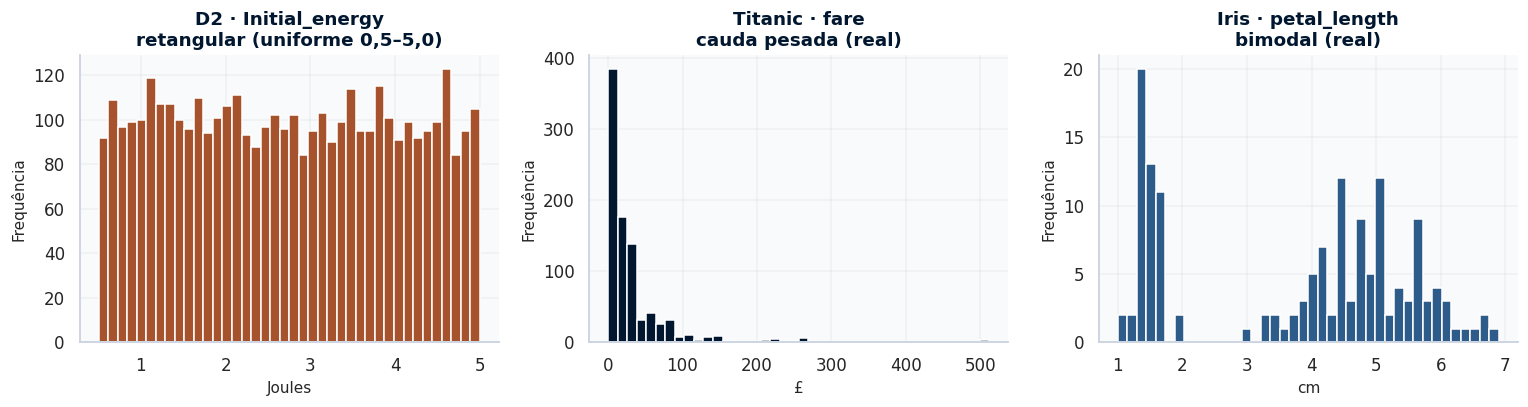

In [25]:
# @title ▶️ 📌 9. Evidência visual
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))

ax[0].hist(df["Initial_energy"], bins=40, color=nu.PALETA["rust"], edgecolor="white")
ax[0].set_title("D2 · Initial_energy\nretangular (uniforme 0,5–5,0)")
ax[0].set_xlabel("Joules")

ax[1].hist(titanic["fare"].dropna(), bins=40, color=nu.PALETA["navy"], edgecolor="white")
ax[1].set_title("Titanic · fare\ncauda pesada (real)")
ax[1].set_xlabel("£")

ax[2].hist(iris["petal_length"], bins=40, color=nu.PALETA["steel"], edgecolor="white")
ax[2].set_title("Iris · petal_length\nbimodal (real)")
ax[2].set_xlabel("cm")

for a in ax: a.set_ylabel("Frequência")
plt.tight_layout(); plt.show()

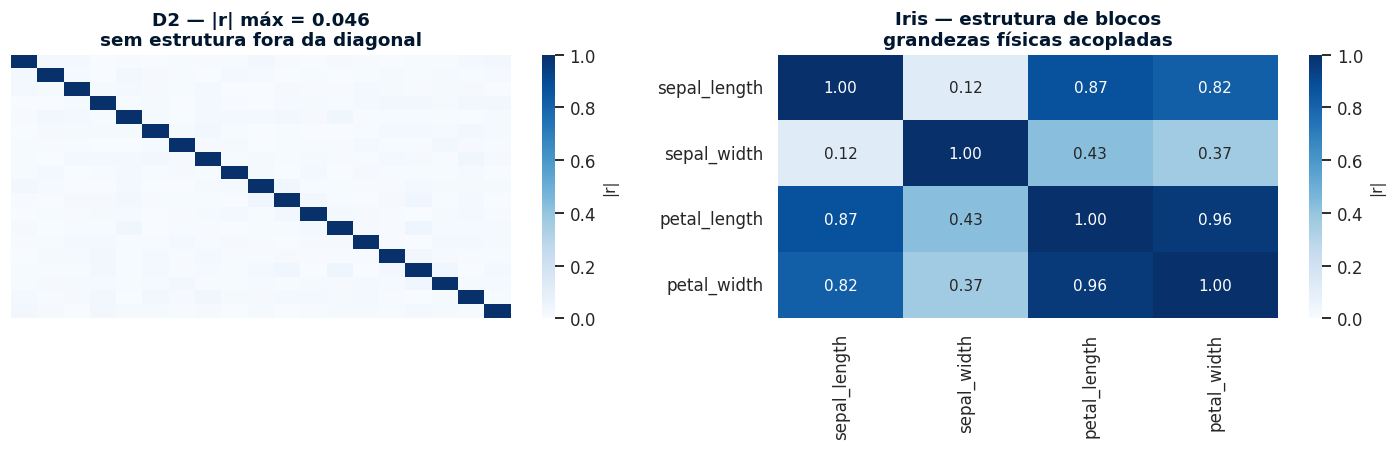

In [26]:
# @title ▶️ 📌 9. Evidência visual
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

sns.heatmap(df[num].corr().abs(), cmap="Blues", vmin=0, vmax=1, ax=ax[0],
            cbar_kws={"label": "|r|"}, xticklabels=False, yticklabels=False)
ax[0].set_title(f"D2 — |r| máx = {off.max():.3f}\nsem estrutura fora da diagonal")

num_iris = iris.select_dtypes(include=[np.number])
sns.heatmap(num_iris.corr().abs(), cmap="Blues", vmin=0, vmax=1, annot=True,
            fmt=".2f", ax=ax[1], cbar_kws={"label": "|r|"})
ax[1].set_title("Iris — estrutura de blocos\ngrandezas físicas acopladas")

plt.tight_layout(); plt.show()

> ✅ **Leitura principal**
>
> A forma das distribuições é discriminante: retângulo, cauda pesada
> e bimodalidade. Dados reais raramente produzem histograma retangular.

O mapa de calor do D2 é uniformemente claro fora da diagonal; o do Iris apresenta blocos
escuros. **Ausência de correlação onde o domínio exige correlação é a assinatura mais
robusta de dado fabricado** — mais que a uniformidade, que pode ser legítima em
contadores cíclicos e identificadores sorteados.

---

## 💾 10. Registro dos achados

In [27]:
# @title ▶️ 💾 10. Registro dos achados
achados = {
    "entrega": "1.2",
    "dataset": "IoT Network Security and Energy (Kaggle, zara2099)",
    "md5": integridade["md5"],
    "linhas": int(len(df)), "colunas": int(df.shape[1]),
    "veredito": veredito["veredito"],
    "sinais_de_sintetico": veredito["sinais_de_sintetico"],
    "colunas_uniformes": list(veredito["uniformes"]),
    "colunas_sem_outliers": list(veredito["sem_outliers"]),
    "corr_max_entre_features": round(veredito["corr_max_entre_features"], 4),
    "features_informativas": veredito["features_informativas"],
    "duplicatas": dup_total,
    "ausencias_totais": int(df.isna().sum().sum()),
    "vazamento": ["LABEL"],
    "proveniencia_declarada": sorted(df["DATASET"].astype(str).unique()),
    "validacao_falsos_positivos": 0,
    "controle_tamanho_amostral": "veredito de D3 invariante a n=4.000 e n=1.000",
    "convencoes": nu.CONVENCOES,
}
json.dump(achados, open("resultados/entrega_1_2.json", "w"), indent=2, ensure_ascii=False)
print(json.dumps(achados, indent=2, ensure_ascii=False))

{
  "entrega": "1.2",
  "dataset": "IoT Network Security and Energy (Kaggle, zara2099)",
  "md5": "cd09503e4bec",
  "linhas": 4000,
  "colunas": 24,
  "veredito": "sintetico",
  "sinais_de_sintetico": 3,
  "colunas_uniformes": [
    15,
    20
  ],
  "colunas_sem_outliers": [
    20,
    20
  ],
  "corr_max_entre_features": 0.0461,
  "features_informativas": 1,
  "duplicatas": 0,
  "ausencias_totais": 0,
  "vazamento": [
    "LABEL"
  ],
  "proveniencia_declarada": [
    "NF-BoT-IoT-v2",
    "NF-CSE-CIC-IDS2018-v2",
    "NF-ToN-IoT-v2"
  ],
  "validacao_falsos_positivos": 0,
  "controle_tamanho_amostral": "veredito de D3 invariante a n=4.000 e n=1.000",
  "convencoes": {
    "quantil": "linear",
    "ddof": 1,
    "outlier": "1.5*IQR",
    "corr": "pearson"
  }
}


---

## 🚀 11. Conclusões e recomendações

### 11.1 Veredito

O conjunto é **sintético**. Três dos cinco sinais acionados, com zero falso positivo
nos controles e invariância ao tamanho amostral.

| # | Teste | Resultado |
|---|---|---|
| 1 | Uniformidade (KS, α = 0,05) | **15 de 19** colunas indistinguíveis de uniforme |
| 2 | Outliers (regra de Tukey) | **19 de 19** colunas sem nenhum outlier |
| 3 | Acoplamento entre variáveis | \|r\| máximo = **0,046** |
| 4 | Independência (χ²) | `Device_Type` e `DATASET` independentes de `ATTACK` |
| 5 | Poder de separação (η²) | **1** variável informativa — e é vazamento |

### 11.2 Incoerências não estatísticas

1. **Esquema incompatível.** Parâmetros de entrada de simulação de rádio (modelo LEACH)
   combinados a campos observados de fluxo de rede.
2. **Proveniência declarada sem lastro.** A coluna `DATASET` cita `NF-ToN-IoT-v2`,
   `NF-BoT-IoT-v2` e `NF-CSE-CIC-IDS2018-v2`. São conjuntos NetFlow reais e
   documentados, e **nenhum deles possui estas colunas**.
3. **`Device_ID` é contador de linha** — `Device_1` a `Device_4000`, um por registro.

### 11.3 Procedimento recomendado para ingestão

1. **Ler o esquema quanto à coerência de domínio** antes de qualquer estatística.
2. **Aplicar os cinco testes.** Custo de segundos.
3. **Validar o detector contra controles conhecidos** — sem isso o veredito não é
   auditável.
4. **Verificar invariância ao tamanho amostral** quando se comparam conjuntos de
   dimensões distintas.
5. **Preferir fontes com publicação associada.** A Entrega 1.3 utiliza o RT-IoT2022
   (UCI #942), com metodologia de captura documentada.

### 11.4 Relevância para segurança operacional

Validação de proveniência é problema corrente em ambientes OT. Decisão tomada sobre
dado fabricado é pior que decisão nenhuma, porque acompanha confiança injustificada.

### 11.5 Continuidade

A Entrega 1.3 aplica o mesmo procedimento ao RT-IoT2022 como controle negativo, e em
seguida conduz a análise substantiva.

---

## 💾 Apêndice A — Registro de decisões

Decisões metodológicas tomadas nesta entrega, com a alternativa descartada e a
justificativa. Serve para que a revisão questione a escolha, não a omissão.

| Decisão | Alternativa descartada | Justificativa |
|---|---|---|
| Reformular a pergunta de pesquisa | descartar a entrega | o procedimento de verificação tem valor próprio e valida o veredito favorável da Entrega 1.3 |
| Não aplicar limpeza | pipeline de limpeza completo | limpar dados sem sinal não cria sinal; produziria aparência de análise sobre ruído |
| Redação "documentação não declara a natureza sintética" | afirmar fabricação intencional | a evidência sustenta a natureza dos dados, não a intenção de quem os publicou |
| Incluir controle de tamanho amostral (8.2) | comparar apenas os originais | o poder dos testes cresce com n; sem o controle, a divergência de vereditos seria contestável |
| Contabilizar variáveis informativas além do η² máximo | usar apenas o máximo | o η² máximo do Iris e do D2 é numericamente próximo mas de natureza oposta |


---

## 🧰 Apêndice B — Referência rápida

**Os cinco testes**

```python
from scipy import stats
# 1. uniformidade
stats.kstest((s - s.min())/(s.max() - s.min()), 'uniform').pvalue
# 2. cauda
nu.outliers(s).sum()
# 3. acoplamento
df[num].corr().abs()
# 4. independência categórica
stats.chi2_contingency(pd.crosstab(df['a'], df['b']))
# 5. consolidação
nu.detectar_sintetico(df, alvo)
```

**Indicadores de fabricação**

```python
distribuição retangular com limites redondos
ausência total de outliers
|r| baixo entre grandezas fisicamente acopladas
nenhuma variável informativa sobre o alvo
identificador sequencial 1..N
esquema combinando domínios incompatíveis
ausência total de valores faltantes
```

**Validação obrigatória**

```python
# taxa de falso positivo contra proveniência conhecida
nu.detectar_sintetico(iris, 'species')      # esperado: real
nu.detectar_sintetico(titanic, 'survived')  # esperado: real
# invariância ao tamanho amostral
nu.detectar_sintetico(grande.sample(n, random_state=42), alvo)
```